In [1]:
import os
import time
import numpy as np
import polars as pl
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
# from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ART

from art.attacks.evasion import ProjectedGradientDescent, FastGradientMethod
from art.estimators.classification import TensorFlowV2Classifier, SklearnClassifier, XGBoostClassifier, LightGBMClassifier, CatBoostARTClassifier, KerasClassifier


I0000 00:00:1778085360.492320 3177087 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778085360.544650 3177087 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778085361.808650 3177087 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packa

In [2]:
# Carga Dataset UNSW-NB15

path_train = "../../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv"
path_test  = "../../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv"
TARGET_COL = "attack_cat"

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)

y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

x_train = df_train.drop(TARGET_COL)
x_test  = df_test.drop(TARGET_COL)

X_full_train = x_train.to_numpy().astype(np.float32)
X_test_np = x_test.to_numpy().astype(np.float32)
y_full_train = y_train.to_numpy()
y_test_np = y_test.to_numpy()

y_full_train_01 = ((y_full_train + 1) // 2).astype(np.int8)
y_test_np01 = ((y_test_np + 1) // 2).astype(np.int8)

# Preparamos una sola vez las distintas vistas del dataset.
# Mantenemos el espacio original para restricciones tabulares y transferencia
# entre modelos que no comparten el mismo preprocesado.
mlp_scaler = StandardScaler()
X_train_scaled_mlp = mlp_scaler.fit_transform(X_full_train).astype(np.float32)
X_test_scaled_mlp = mlp_scaler.transform(X_test_np).astype(np.float32)

cnn_scaler = MinMaxScaler()
X_train_scaled_cnn = cnn_scaler.fit_transform(X_full_train).astype(np.float32)
X_test_scaled_cnn = cnn_scaler.transform(X_test_np).astype(np.float32)

DATASET_VIEWS = {
    "raw": {"train": X_full_train, "test": X_test_np},
    "standard": {"train": X_train_scaled_mlp, "test": X_test_scaled_mlp},
    "minmax": {"train": X_train_scaled_cnn, "test": X_test_scaled_cnn},
}

print(f"Train: {X_full_train.shape} | Test: {X_test_np.shape}")
print("Tras convertir -1/1 a 0/1, la clase 0 corresponde a Ataque y la clase 1 a Normal.")
print("Vistas disponibles:", ", ".join(DATASET_VIEWS.keys()))

HAS_GPU = len(tf.config.list_physical_devices("GPU")) > 0
TRAIN_DEVICE = "/GPU:0" if HAS_GPU else "/CPU:0"
INFER_DEVICE = "/CPU:0"


Train: (175341, 12) | Test: (82332, 12)
Tras convertir -1/1 a 0/1, la clase 0 corresponde a Ataque y la clase 1 a Normal.
Vistas disponibles: raw, standard, minmax


In [3]:
# Modelos ganadores de UNSW-NB15

RF_CONFIG = {"n_estimators": 50, "max_depth": 23}
XGB_CONFIG = {"n_estimators": 200, "max_depth": 11, "learning_rate": 0.1}
LGBM_CONFIG = {"n_estimators": 100, "num_leaves": 145, "max_depth": 12, "learning_rate": 0.1}
CATBOOST_CONFIG = {"iterations": 500, "depth": 10, "learning_rate": 0.1}

SVM_C = 0.000187
MLP_INPUT_DIM = X_full_train.shape[1]
CNN1D_CONFIG = {"nf": 64, "k": 5, "d": 48}

def build_mlp_model(input_dim):
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(input_dim,)),
        keras.layers.Dense(96, activation="relu"),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

DEFAULT_CNN_DROPOUT = 0.2

def build_cnn1d_model(n_features, n_filters, kernel_size, dense_units, dropout_rate=DEFAULT_CNN_DROPOUT):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features, 1)),
        keras.layers.Conv1D(filters=n_filters, kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(filters=max(16, n_filters // 2), kernel_size=kernel_size, padding="same", activation="relu"),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(dense_units, activation="relu"),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def clone_keras_model_to_cpu(builder_fn, trained_model, *builder_args):
    with tf.device(INFER_DEVICE):
        cpu_model = builder_fn(*builder_args)
        cpu_model.set_weights(trained_model.get_weights())
    return cpu_model

In [4]:
# Entrenamiento modelos con su dataset

print("Entrenando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=RF_CONFIG["n_estimators"],
    max_depth=RF_CONFIG["max_depth"],
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_full_train, y_full_train_01)

# ==========================================

print("\nEntrenando XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=XGB_CONFIG["n_estimators"],
    max_depth=XGB_CONFIG["max_depth"],
    learning_rate=XGB_CONFIG["learning_rate"],
    tree_method="hist",
    device="cuda" if HAS_GPU else "cpu",
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_full_train, y_full_train_01)

# ==========================================

print("\nEntrenando LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=LGBM_CONFIG["n_estimators"],
    num_leaves=LGBM_CONFIG["num_leaves"],
    max_depth=LGBM_CONFIG["max_depth"],
    learning_rate=LGBM_CONFIG["learning_rate"],
    device_type="gpu" if HAS_GPU else "cpu",
    n_jobs=-1,
    random_state=42,
    verbosity=-1
)
lgbm_model.fit(X_full_train, y_full_train_01)

# ==========================================
print("\nEntrenando CatBoost...")
cat_model = CatBoostClassifier(
    iterations=CATBOOST_CONFIG["iterations"],
    depth=CATBOOST_CONFIG["depth"],
    learning_rate=CATBOOST_CONFIG["learning_rate"],
    random_seed=42,
    logging_level="Silent",
    task_type="GPU" if HAS_GPU else "CPU"
)
cat_model.fit(X_full_train, y_full_train_01)


Entrenando Random Forest...

Entrenando XGBoost...

Entrenando LightGBM...

Entrenando CatBoost...


CatBoostClassifier(depth=10, iterations=500, learning_rate=0.1, logging_level='Silent', random_seed=42, task_type='GPU')

In [5]:
# ==========================================

print("\nEntrenando Linear SVM...")
svm_model = LinearSVC(C=SVM_C, dual=False, random_state=42, max_iter=2000)
svm_model.fit(X_train_scaled_mlp, y_full_train_01)

# ==========================================

print("\nEntrenando MLP...")
tf.keras.backend.clear_session()
with tf.device(INFER_DEVICE):
    mlp_model = build_mlp_model(MLP_INPUT_DIM)
    mlp_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    mlp_model.fit(
        X_train_scaled_mlp,
        y_full_train_01,
        validation_split=0.1,
        epochs=40,
        batch_size=2048,
        callbacks=[mlp_early],
        verbose=0
    )

# ==========================================

print("\nEntrenando CNN-1D...")
tf.keras.backend.clear_session()
X_train_tabular_cnn = X_train_scaled_cnn.reshape(X_train_scaled_cnn.shape[0], X_train_scaled_cnn.shape[1], 1)
X_test_tabular_cnn = X_test_scaled_cnn.reshape(X_test_scaled_cnn.shape[0], X_test_scaled_cnn.shape[1], 1)
with tf.device(INFER_DEVICE):
    cnn_model = build_cnn1d_model(X_train_tabular_cnn.shape[1], CNN1D_CONFIG["nf"], CNN1D_CONFIG["k"], CNN1D_CONFIG["d"])
    cnn_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    cnn_model.fit(
        X_train_tabular_cnn,
        y_full_train_01,
        validation_split=0.1,
        epochs=20,
        batch_size=1024,
        callbacks=[cnn_early],
        verbose=0
    )



Entrenando Linear SVM...

Entrenando MLP...


I0000 00:00:1778086350.851510 3177087 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43415 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
I0000 00:00:1778086350.862919 3177087 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43485 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9
I0000 00:00:1778086350.865931 3177087 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 16340 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:ca:00.0, compute capability: 8.9
I0000 00:00:1778086350.871101 3177087 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 39112 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:


Entrenando CNN-1D...


Una vez que los modelos ya están entrenados, ya podemos entrar en la fase de Evaluación Adversaria. Primero vamos a ver que nuestro modelo recién entrenado rinda bien con x_test limpio

In [6]:
# Evaluamos en test MLP

mlp_model_cpu = clone_keras_model_to_cpu(build_mlp_model, mlp_model, MLP_INPUT_DIM)
def mlp_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)
def mlp_predict_scores(X):
    with tf.device(INFER_DEVICE):
        return mlp_model_cpu.predict(X, batch_size=4096, verbose=0).ravel()

# F1-score de referencia en test para MLP
y_test_pred_mlp = mlp_predict_labels(X_test_scaled_mlp)
mlp_f1 = f1_score(y_test_np01, y_test_pred_mlp)
print(f"\nMLP F1-score en test: {mlp_f1:.4f}")


MLP F1-score en test: 0.7053


In [17]:
# Extraemos restricciones tabulares a partir del train original
feature_names = x_train.columns

tabular_constraints_df = pl.DataFrame({
    "feature": feature_names,
    "min": x_train.min().row(0),
    "max": x_train.max().row(0),
})

feature_mins = tabular_constraints_df["min"].to_numpy().astype(np.float32)
feature_maxs = tabular_constraints_df["max"].to_numpy().astype(np.float32)

tabular_constraints = {
    feature: {"min": float(min_val), "max": float(max_val)}
    for feature, min_val, max_val in zip(feature_names, feature_mins, feature_maxs)
}

# 1. Restricciones para modelos que trabajan en espacio original
clip_values_raw = (feature_mins, feature_maxs)

# 2. Restricciones para el MLP, que trabaja con StandardScaler
feature_mins_mlp = mlp_scaler.transform(feature_mins.reshape(1, -1)).ravel().astype(np.float32)
feature_maxs_mlp = mlp_scaler.transform(feature_maxs.reshape(1, -1)).ravel().astype(np.float32)
clip_values_mlp = (feature_mins_mlp, feature_maxs_mlp)

# 3. Restricciones para la CNN, que trabaja con MinMaxScaler
feature_mins_cnn = cnn_scaler.transform(feature_mins.reshape(1, -1)).reshape(-1, 1).astype(np.float32)
feature_maxs_cnn = cnn_scaler.transform(feature_maxs.reshape(1, -1)).reshape(-1, 1).astype(np.float32)
clip_values_cnn = (feature_mins_cnn, feature_maxs_cnn)

print("Restricciones tabulares extraidas para UNSW-NB15:")
display(tabular_constraints_df)

print(clip_values_mlp)

Restricciones tabulares extraidas para UNSW-NB15:


feature,min,max
str,f64,f64
"""dur""",0.0,59.999989
"""sinpkt""",0.0,84371.496
"""dinpkt""",0.0,56716.824
"""spkts""",1.0,9616.0
"""dpkts""",0.0,10974.0
…,…,…
"""rate""",0.0,1.0000e6
"""smean""",28.0,1504.0
"""dmean""",0.0,1458.0


(array([-0.20977475, -0.1361428 , -0.08937003, -0.14098223, -0.17204736,
       -0.05044967, -0.10392289, -0.57681924, -0.5313342 , -0.48070285,
       -0.48434597, -0.50301373], dtype=float32), array([  9.049153 ,  11.513798 ,  57.369225 ,  70.09933  ,  99.358185 ,
        74.135994 , 101.91599  ,   5.469112 ,   6.6800365,   5.1635404,
        47.911243 ,  37.04389  ], dtype=float32))


In [18]:
# Hay que tener en cuenta que si tuviéramos columnas One Hot Encoding, habría que asegurarse de que las restricciones 
# se apliquen correctamente y que ART no me genere un TCP = 0.62, ya que no tiene sentido que un valor One Hot Encoding tenga un valor intermedio entre 0 y 1. 
# En ese caso habría que indicarle a ART que esas columnas solo pueden tomar valores 0 o 1, y no valores continuos.

# ==========================================
# FASE 1. ENVOLVER EL MODELO (Caja Blanca)
# ==========================================

print("Envolviendo el modelo MLP en ART con restricciones tabulares...")

clasificador_art_mlp = KerasClassifier(
    model=mlp_model_cpu, 
    clip_values=clip_values_mlp, 
    use_logits=False
)

print("Envolviendo el modelo CNN en ART con restricciones tabulares...")

cnn_model_cpu = clone_keras_model_to_cpu(
    build_cnn1d_model,
    cnn_model,
    X_train_tabular_cnn.shape[1],
    CNN1D_CONFIG["nf"],
    CNN1D_CONFIG["k"],
    CNN1D_CONFIG["d"]
)

clasificador_art_cnn = KerasClassifier(
    model=cnn_model_cpu,
    clip_values=clip_values_cnn,
    use_logits=False
)


Envolviendo el modelo MLP en ART con restricciones tabulares...
Envolviendo el modelo CNN en ART con restricciones tabulares...


In [19]:
# ===================================================
# FASE 2. FUERZA DE ATAQUE POR CARACTERÍSTICA (eps)
# ===================================================

print("Configurando la fuerza del ataque (eps) por característica...")

# Definimos la fuerza base del ataque como un 20% del rango permitido
# por cada característica en el espacio escalado del MLP.
eps_base = 0.01 # Cuánto permitimos que se modifique cada característica

feature_ranges_mlp = clip_values_mlp[1] - clip_values_mlp[0]
eps_vector = (eps_base * feature_ranges_mlp).astype(np.float32)
eps_step_vector = np.where(eps_vector > 0, eps_vector / 4.0, 0.0).astype(np.float32) # El tamaño del paso
print(eps_vector)
print(eps_step_vector)

feature_ranges_cnn = clip_values_cnn[1] - clip_values_cnn[0]
eps_vector_cnn = (eps_base * feature_ranges_cnn).astype(np.float32)
eps_step_vector_cnn = np.where(eps_vector_cnn > 0, eps_vector_cnn / 4.0, 0.0).astype(np.float32)
print(eps_vector_cnn)
print(eps_step_vector_cnn)

Configurando la fuerza del ataque (eps) por característica...
[0.09258928 0.1164994  0.5745859  0.70240307 0.9953023  0.74186444
 1.0201991  0.06045931 0.07211371 0.05644243 0.48395586 0.37546906]
[0.02314732 0.02912485 0.14364648 0.17560077 0.24882558 0.18546611
 0.25504977 0.01511483 0.01802843 0.01411061 0.12098897 0.09386726]
[[0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]
 [0.01]]
[[0.0025]
 [0.0025]
 [0.0025]
 [0.0025]
 [0.0025]
 [0.0025]
 [0.0025]
 [0.0025]
 [0.0025]
 [0.0025]
 [0.0025]
 [0.0025]]


In [14]:
# =======================================================
# FASE 3. LANZAR ATAQUE PGD CON RESTRICCIONES TABULARES
# =======================================================

print("Lanzando ataque PGD sobre MLP y CNN...")

# -----------------------------
# PGD sobre el MLP
# -----------------------------
ataque_pgd_mlp = ProjectedGradientDescent(
    estimator=clasificador_art_mlp,
    eps=eps_vector,
    eps_step=eps_step_vector,
    max_iter=20,
    batch_size=128
)

# Atacamos el conjunto en el mismo espacio que usa el MLP
x_test_mlp_attack = X_test_scaled_mlp.astype(np.float32)

# Generamos el dataset adversario para el MLP
x_test_pgd_mlp = ataque_pgd_mlp.generate(x=x_test_mlp_attack)
print("¡Tráfico adversario PGD para el MLP generado con éxito!")

Lanzando ataque PGD sobre MLP y CNN...


PGD - Random Initializations: 100%|██████████| 1/1 [00:00<00:00,  6.58it/s]

¡Tráfico adversario PGD para el MLP generado con éxito!


In [20]:
# -----------------------------
# PGD sobre la CNN
# -----------------------------


ataque_pgd_cnn = ProjectedGradientDescent(
    estimator=clasificador_art_cnn,
    eps=eps_vector_cnn,
    eps_step=eps_step_vector_cnn,
    max_iter=20,
    batch_size=128
)

x_test_cnn_attack = X_test_tabular_cnn.astype(np.float32)

with tf.device(INFER_DEVICE):
    x_test_pgd_cnn = ataque_pgd_cnn.generate(x=x_test_cnn_attack)

print("¡Tráfico adversario PGD para la CNN generado con éxito!")


PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Random Initializations: 100%|██████████| 1/1 [00:00<00:00,  3.87it/s]


¡Tráfico adversario PGD para la CNN generado con éxito!


In [21]:
# =======================================================================
# ADAPTACIÓN DE LOS DATASETS ADVERSARIOS PARA EVALUACIÓN EN AMBOS MODELOS
# =======================================================================

def cnn_predict_labels(X):
    with tf.device(INFER_DEVICE):
        y_prob = cnn_model.predict(X, batch_size=4096, verbose=0).ravel()
    return (y_prob > 0.5).astype(np.int8)

# =========================
# PGD generado sobre MLP
# =========================
x_test_pgd_mlp_std = x_test_pgd_mlp.astype(np.float32)
x_test_pgd_mlp_raw = mlp_scaler.inverse_transform(x_test_pgd_mlp_std).astype(np.float32)
x_test_pgd_mlp_minmax = cnn_scaler.transform(x_test_pgd_mlp_raw).astype(np.float32)
x_test_pgd_mlp_cnn = x_test_pgd_mlp_minmax.reshape(
    x_test_pgd_mlp_minmax.shape[0],
    x_test_pgd_mlp_minmax.shape[1],
    1
)

# =========================
# PGD generado sobre CNN
# =========================
x_test_pgd_cnn_cnn = x_test_pgd_cnn.astype(np.float32)
x_test_pgd_cnn_minmax = x_test_pgd_cnn_cnn.reshape(
    x_test_pgd_cnn_cnn.shape[0],
    x_test_pgd_cnn_cnn.shape[1]
).astype(np.float32)
x_test_pgd_cnn_raw = cnn_scaler.inverse_transform(x_test_pgd_cnn_minmax).astype(np.float32)
x_test_pgd_cnn_std = mlp_scaler.transform(x_test_pgd_cnn_raw).astype(np.float32)


In [23]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

# =====================================================
# RF
# =====================================================
y_test_pred_rf_clean = rf_model.predict(X_test_np)
rf_acc_clean = accuracy_score(y_test_np01, y_test_pred_rf_clean)
rf_f1_clean = f1_score(y_test_np01, y_test_pred_rf_clean)
rf_recall_clean = recall_score(y_test_np01, y_test_pred_rf_clean)

print(f"\nRF Accuracy limpio: {rf_acc_clean:.4f}")
print(f"RF F1 limpio: {rf_f1_clean:.4f}")
print(f"RF Recall limpio: {rf_recall_clean:.4f}")

y_test_pred_rf_pgd_mlp = rf_model.predict(x_test_pgd_mlp_raw)
rf_acc_pgd_mlp = accuracy_score(y_test_np01, y_test_pred_rf_pgd_mlp)
rf_f1_pgd_mlp = f1_score(y_test_np01, y_test_pred_rf_pgd_mlp)
rf_recall_pgd_mlp = recall_score(y_test_np01, y_test_pred_rf_pgd_mlp)

print(f"\nRF Accuracy PGD-MLP: {rf_acc_pgd_mlp:.4f}")
print(f"RF F1 PGD-MLP: {rf_f1_pgd_mlp:.4f}")
print(f"RF Recall PGD-MLP: {rf_recall_pgd_mlp:.4f}")

y_test_pred_rf_pgd_cnn = rf_model.predict(x_test_pgd_cnn_raw)
rf_acc_pgd_cnn = accuracy_score(y_test_np01, y_test_pred_rf_pgd_cnn)
rf_f1_pgd_cnn = f1_score(y_test_np01, y_test_pred_rf_pgd_cnn)
rf_recall_pgd_cnn = recall_score(y_test_np01, y_test_pred_rf_pgd_cnn)

print(f"\nRF Accuracy PGD-CNN: {rf_acc_pgd_cnn:.4f}")
print(f"RF F1 PGD-CNN: {rf_f1_pgd_cnn:.4f}")
print(f"RF Recall PGD-CNN: {rf_recall_pgd_cnn:.4f}")

# =====================================================
# XGBOOST
# =====================================================
y_test_pred_xgb_clean = xgb_model.predict(X_test_np)
xgb_acc_clean = accuracy_score(y_test_np01, y_test_pred_xgb_clean)
xgb_f1_clean = f1_score(y_test_np01, y_test_pred_xgb_clean)
xgb_recall_clean = recall_score(y_test_np01, y_test_pred_xgb_clean)

print(f"\nXGB Accuracy limpio: {xgb_acc_clean:.4f}")
print(f"XGB F1 limpio: {xgb_f1_clean:.4f}")
print(f"XGB Recall limpio: {xgb_recall_clean:.4f}")

y_test_pred_xgb_pgd_mlp = xgb_model.predict(x_test_pgd_mlp_raw)
xgb_acc_pgd_mlp = accuracy_score(y_test_np01, y_test_pred_xgb_pgd_mlp)
xgb_f1_pgd_mlp = f1_score(y_test_np01, y_test_pred_xgb_pgd_mlp)
xgb_recall_pgd_mlp = recall_score(y_test_np01, y_test_pred_xgb_pgd_mlp)

print(f"\nXGB Accuracy PGD-MLP: {xgb_acc_pgd_mlp:.4f}")
print(f"XGB F1 PGD-MLP: {xgb_f1_pgd_mlp:.4f}")
print(f"XGB Recall PGD-MLP: {xgb_recall_pgd_mlp:.4f}")

y_test_pred_xgb_pgd_cnn = xgb_model.predict(x_test_pgd_cnn_raw)
xgb_acc_pgd_cnn = accuracy_score(y_test_np01, y_test_pred_xgb_pgd_cnn)
xgb_f1_pgd_cnn = f1_score(y_test_np01, y_test_pred_xgb_pgd_cnn)
xgb_recall_pgd_cnn = recall_score(y_test_np01, y_test_pred_xgb_pgd_cnn)

print(f"\nXGB Accuracy PGD-CNN: {xgb_acc_pgd_cnn:.4f}")
print(f"XGB F1 PGD-CNN: {xgb_f1_pgd_cnn:.4f}")
print(f"XGB Recall PGD-CNN: {xgb_recall_pgd_cnn:.4f}")

# =====================================================
# LIGHTGBM
# =====================================================
y_test_pred_lgbm_clean = lgbm_model.predict(X_test_np)
lgbm_acc_clean = accuracy_score(y_test_np01, y_test_pred_lgbm_clean)
lgbm_f1_clean = f1_score(y_test_np01, y_test_pred_lgbm_clean)
lgbm_recall_clean = recall_score(y_test_np01, y_test_pred_lgbm_clean)

print(f"\nLGBM Accuracy limpio: {lgbm_acc_clean:.4f}")
print(f"LGBM F1 limpio: {lgbm_f1_clean:.4f}")
print(f"LGBM Recall limpio: {lgbm_recall_clean:.4f}")

y_test_pred_lgbm_pgd_mlp = lgbm_model.predict(x_test_pgd_mlp_raw)
lgbm_acc_pgd_mlp = accuracy_score(y_test_np01, y_test_pred_lgbm_pgd_mlp)
lgbm_f1_pgd_mlp = f1_score(y_test_np01, y_test_pred_lgbm_pgd_mlp)
lgbm_recall_pgd_mlp = recall_score(y_test_np01, y_test_pred_lgbm_pgd_mlp)

print(f"\nLGBM Accuracy PGD-MLP: {lgbm_acc_pgd_mlp:.4f}")
print(f"LGBM F1 PGD-MLP: {lgbm_f1_pgd_mlp:.4f}")
print(f"LGBM Recall PGD-MLP: {lgbm_recall_pgd_mlp:.4f}")

y_test_pred_lgbm_pgd_cnn = lgbm_model.predict(x_test_pgd_cnn_raw)
lgbm_acc_pgd_cnn = accuracy_score(y_test_np01, y_test_pred_lgbm_pgd_cnn)
lgbm_f1_pgd_cnn = f1_score(y_test_np01, y_test_pred_lgbm_pgd_cnn)
lgbm_recall_pgd_cnn = recall_score(y_test_np01, y_test_pred_lgbm_pgd_cnn)

print(f"\nLGBM Accuracy PGD-CNN: {lgbm_acc_pgd_cnn:.4f}")
print(f"LGBM F1 PGD-CNN: {lgbm_f1_pgd_cnn:.4f}")
print(f"LGBM Recall PGD-CNN: {lgbm_recall_pgd_cnn:.4f}")

# =====================================================
# CATBOOST
# =====================================================
y_test_pred_cat_clean = cat_model.predict(X_test_np)
cat_acc_clean = accuracy_score(y_test_np01, y_test_pred_cat_clean)
cat_f1_clean = f1_score(y_test_np01, y_test_pred_cat_clean)
cat_recall_clean = recall_score(y_test_np01, y_test_pred_cat_clean)

print(f"\nCatBoost Accuracy limpio: {cat_acc_clean:.4f}")
print(f"CatBoost F1 limpio: {cat_f1_clean:.4f}")
print(f"CatBoost Recall limpio: {cat_recall_clean:.4f}")

y_test_pred_cat_pgd_mlp = cat_model.predict(x_test_pgd_mlp_raw)
cat_acc_pgd_mlp = accuracy_score(y_test_np01, y_test_pred_cat_pgd_mlp)
cat_f1_pgd_mlp = f1_score(y_test_np01, y_test_pred_cat_pgd_mlp)
cat_recall_pgd_mlp = recall_score(y_test_np01, y_test_pred_cat_pgd_mlp)

print(f"\nCatBoost Accuracy PGD-MLP: {cat_acc_pgd_mlp:.4f}")
print(f"CatBoost F1 PGD-MLP: {cat_f1_pgd_mlp:.4f}")
print(f"CatBoost Recall PGD-MLP: {cat_recall_pgd_mlp:.4f}")

y_test_pred_cat_pgd_cnn = cat_model.predict(x_test_pgd_cnn_raw)
cat_acc_pgd_cnn = accuracy_score(y_test_np01, y_test_pred_cat_pgd_cnn)
cat_f1_pgd_cnn = f1_score(y_test_np01, y_test_pred_cat_pgd_cnn)
cat_recall_pgd_cnn = recall_score(y_test_np01, y_test_pred_cat_pgd_cnn)

print(f"\nCatBoost Accuracy PGD-CNN: {cat_acc_pgd_cnn:.4f}")
print(f"CatBoost F1 PGD-CNN: {cat_f1_pgd_cnn:.4f}")
print(f"CatBoost Recall PGD-CNN: {cat_recall_pgd_cnn:.4f}")

# =====================================================
# SVM
# =====================================================
y_test_pred_svm_clean = svm_model.predict(X_test_scaled_mlp)
svm_acc_clean = accuracy_score(y_test_np01, y_test_pred_svm_clean)
svm_f1_clean = f1_score(y_test_np01, y_test_pred_svm_clean)
svm_recall_clean = recall_score(y_test_np01, y_test_pred_svm_clean)

print(f"\nSVM Accuracy limpio: {svm_acc_clean:.4f}")
print(f"SVM F1 limpio: {svm_f1_clean:.4f}")
print(f"SVM Recall limpio: {svm_recall_clean:.4f}")

y_test_pred_svm_pgd_mlp = svm_model.predict(x_test_pgd_mlp_std)
svm_acc_pgd_mlp = accuracy_score(y_test_np01, y_test_pred_svm_pgd_mlp)
svm_f1_pgd_mlp = f1_score(y_test_np01, y_test_pred_svm_pgd_mlp)
svm_recall_pgd_mlp = recall_score(y_test_np01, y_test_pred_svm_pgd_mlp)

print(f"\nSVM Accuracy PGD-MLP: {svm_acc_pgd_mlp:.4f}")
print(f"SVM F1 PGD-MLP: {svm_f1_pgd_mlp:.4f}")
print(f"SVM Recall PGD-MLP: {svm_recall_pgd_mlp:.4f}")

y_test_pred_svm_pgd_cnn = svm_model.predict(x_test_pgd_cnn_std)
svm_acc_pgd_cnn = accuracy_score(y_test_np01, y_test_pred_svm_pgd_cnn)
svm_f1_pgd_cnn = f1_score(y_test_np01, y_test_pred_svm_pgd_cnn)
svm_recall_pgd_cnn = recall_score(y_test_np01, y_test_pred_svm_pgd_cnn)

print(f"\nSVM Accuracy PGD-CNN: {svm_acc_pgd_cnn:.4f}")
print(f"SVM F1 PGD-CNN: {svm_f1_pgd_cnn:.4f}")
print(f"SVM Recall PGD-CNN: {svm_recall_pgd_cnn:.4f}")

# =====================================================
# MLP
# =====================================================
y_test_pred_mlp_clean = mlp_predict_labels(X_test_scaled_mlp)
mlp_acc_clean = accuracy_score(y_test_np01, y_test_pred_mlp_clean)
mlp_f1_clean = f1_score(y_test_np01, y_test_pred_mlp_clean)
mlp_recall_clean = recall_score(y_test_np01, y_test_pred_mlp_clean)

print(f"\nMLP Accuracy limpio: {mlp_acc_clean:.4f}")
print(f"MLP F1 limpio: {mlp_f1_clean:.4f}")
print(f"MLP Recall limpio: {mlp_recall_clean:.4f}")

y_test_pred_mlp_pgd_mlp = mlp_predict_labels(x_test_pgd_mlp_std)
mlp_acc_pgd_mlp = accuracy_score(y_test_np01, y_test_pred_mlp_pgd_mlp)
mlp_f1_pgd_mlp = f1_score(y_test_np01, y_test_pred_mlp_pgd_mlp)
mlp_recall_pgd_mlp = recall_score(y_test_np01, y_test_pred_mlp_pgd_mlp)

print(f"\nMLP Accuracy PGD-MLP: {mlp_acc_pgd_mlp:.4f}")
print(f"MLP F1 PGD-MLP: {mlp_f1_pgd_mlp:.4f}")
print(f"MLP Recall PGD-MLP: {mlp_recall_pgd_mlp:.4f}")

y_test_pred_mlp_pgd_cnn = mlp_predict_labels(x_test_pgd_cnn_std)
mlp_acc_pgd_cnn = accuracy_score(y_test_np01, y_test_pred_mlp_pgd_cnn)
mlp_f1_pgd_cnn = f1_score(y_test_np01, y_test_pred_mlp_pgd_cnn)
mlp_recall_pgd_cnn = recall_score(y_test_np01, y_test_pred_mlp_pgd_cnn)

print(f"\nMLP Accuracy PGD-CNN: {mlp_acc_pgd_cnn:.4f}")
print(f"MLP F1 PGD-CNN: {mlp_f1_pgd_cnn:.4f}")
print(f"MLP Recall PGD-CNN: {mlp_recall_pgd_cnn:.4f}")

# =====================================================
# CNN
# =====================================================
y_test_pred_cnn_clean = cnn_predict_labels(X_test_tabular_cnn)
cnn_acc_clean = accuracy_score(y_test_np01, y_test_pred_cnn_clean)
cnn_f1_clean = f1_score(y_test_np01, y_test_pred_cnn_clean)
cnn_recall_clean = recall_score(y_test_np01, y_test_pred_cnn_clean)

print(f"\nCNN Accuracy limpio: {cnn_acc_clean:.4f}")
print(f"CNN F1 limpio: {cnn_f1_clean:.4f}")
print(f"CNN Recall limpio: {cnn_recall_clean:.4f}")

y_test_pred_cnn_pgd_mlp = cnn_predict_labels(x_test_pgd_mlp_cnn)
cnn_acc_pgd_mlp = accuracy_score(y_test_np01, y_test_pred_cnn_pgd_mlp)
cnn_f1_pgd_mlp = f1_score(y_test_np01, y_test_pred_cnn_pgd_mlp)
cnn_recall_pgd_mlp = recall_score(y_test_np01, y_test_pred_cnn_pgd_mlp)

print(f"\nCNN Accuracy PGD-MLP: {cnn_acc_pgd_mlp:.4f}")
print(f"CNN F1 PGD-MLP: {cnn_f1_pgd_mlp:.4f}")
print(f"CNN Recall PGD-MLP: {cnn_recall_pgd_mlp:.4f}")

y_test_pred_cnn_pgd_cnn = cnn_predict_labels(x_test_pgd_cnn_cnn)
cnn_acc_pgd_cnn = accuracy_score(y_test_np01, y_test_pred_cnn_pgd_cnn)
cnn_f1_pgd_cnn = f1_score(y_test_np01, y_test_pred_cnn_pgd_cnn)
cnn_recall_pgd_cnn = recall_score(y_test_np01, y_test_pred_cnn_pgd_cnn)

print(f"\nCNN Accuracy PGD-CNN: {cnn_acc_pgd_cnn:.4f}")
print(f"CNN F1 PGD-CNN: {cnn_f1_pgd_cnn:.4f}")
print(f"CNN Recall PGD-CNN: {cnn_recall_pgd_cnn:.4f}")



RF Accuracy limpio: 0.8665
RF F1 limpio: 0.8320
RF Recall limpio: 0.7357

RF Accuracy PGD-MLP: 0.5717
RF F1 PGD-MLP: 0.1089
RF Recall PGD-MLP: 0.0582

RF Accuracy PGD-CNN: 0.4819
RF F1 PGD-CNN: 0.0967
RF Recall PGD-CNN: 0.0617

XGB Accuracy limpio: 0.8641
XGB F1 limpio: 0.8282
XGB Recall limpio: 0.7289

XGB Accuracy PGD-MLP: 0.5956
XGB F1 PGD-MLP: 0.3238
XGB Recall PGD-MLP: 0.2155

XGB Accuracy PGD-CNN: 0.6586
XGB F1 PGD-CNN: 0.4679
XGB Recall PGD-CNN: 0.3340

LGBM Accuracy limpio: 0.8656
LGBM F1 limpio: 0.8299
LGBM Recall limpio: 0.7293

LGBM Accuracy PGD-MLP: 0.7321
LGBM F1 PGD-MLP: 0.7143
LGBM Recall PGD-MLP: 0.7451

LGBM Accuracy PGD-CNN: 0.6905
LGBM F1 PGD-CNN: 0.6138
LGBM Recall PGD-CNN: 0.5473


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



CatBoost Accuracy limpio: 0.8634
CatBoost F1 limpio: 0.8268
CatBoost Recall limpio: 0.7253

CatBoost Accuracy PGD-MLP: 0.5811
CatBoost F1 PGD-MLP: 0.1455
CatBoost Recall PGD-MLP: 0.0794

CatBoost Accuracy PGD-CNN: 0.5218
CatBoost F1 PGD-CNN: 0.0947
CatBoost Recall PGD-CNN: 0.0556

SVM Accuracy limpio: 0.7361
SVM F1 limpio: 0.6208
SVM Recall limpio: 0.4807

SVM Accuracy PGD-MLP: 0.6275
SVM F1 PGD-MLP: 0.3846
SVM Recall PGD-MLP: 0.2590

SVM Accuracy PGD-CNN: 0.6565
SVM F1 PGD-CNN: 0.4838
SVM Recall PGD-CNN: 0.3582

MLP Accuracy limpio: 0.7912
MLP F1 limpio: 0.7053
MLP Recall limpio: 0.5558

MLP Accuracy PGD-MLP: 0.5671
MLP F1 PGD-MLP: 0.0718
MLP Recall PGD-MLP: 0.0372

MLP Accuracy PGD-CNN: 0.6784
MLP F1 PGD-CNN: 0.4522
MLP Recall PGD-CNN: 0.2954

CNN Accuracy limpio: 0.7606
CNN F1 limpio: 0.6461
CNN Recall limpio: 0.4862

CNN Accuracy PGD-MLP: 0.7537
CNN F1 PGD-MLP: 0.6276
CNN Recall PGD-MLP: 0.4617

CNN Accuracy PGD-CNN: 0.6717
CNN F1 PGD-CNN: 0.4284
CNN Recall PGD-CNN: 0.2738


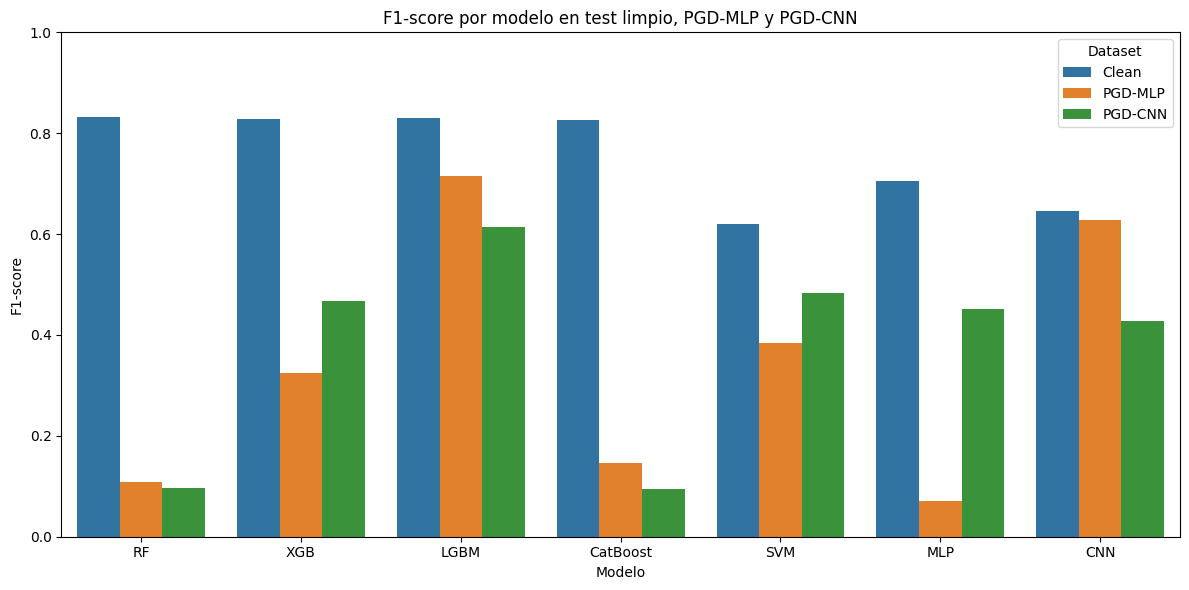

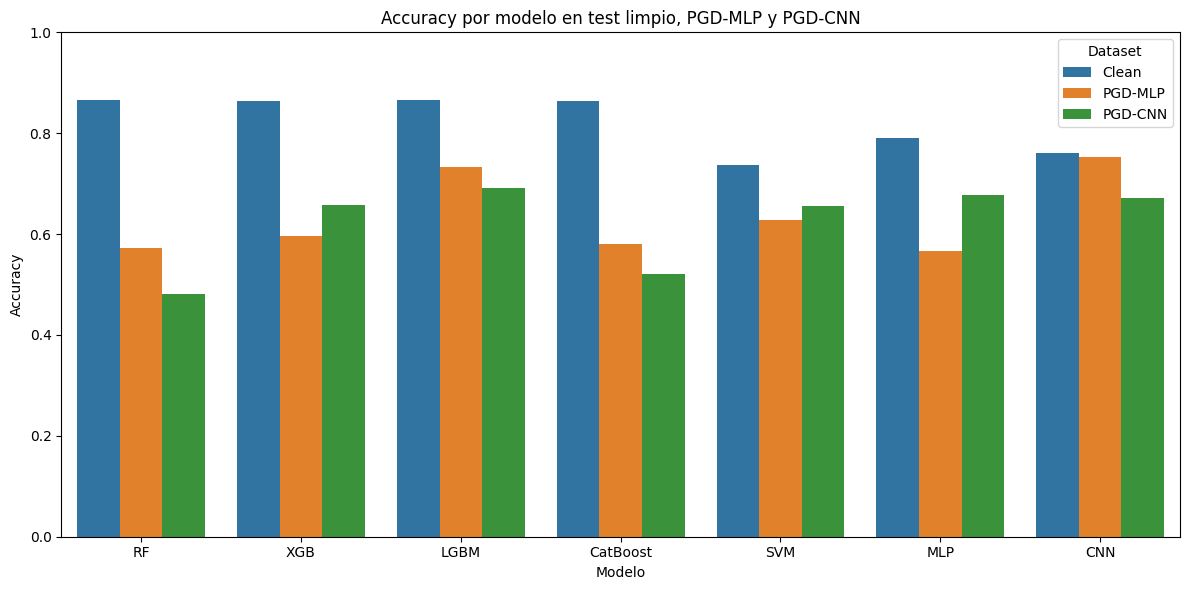

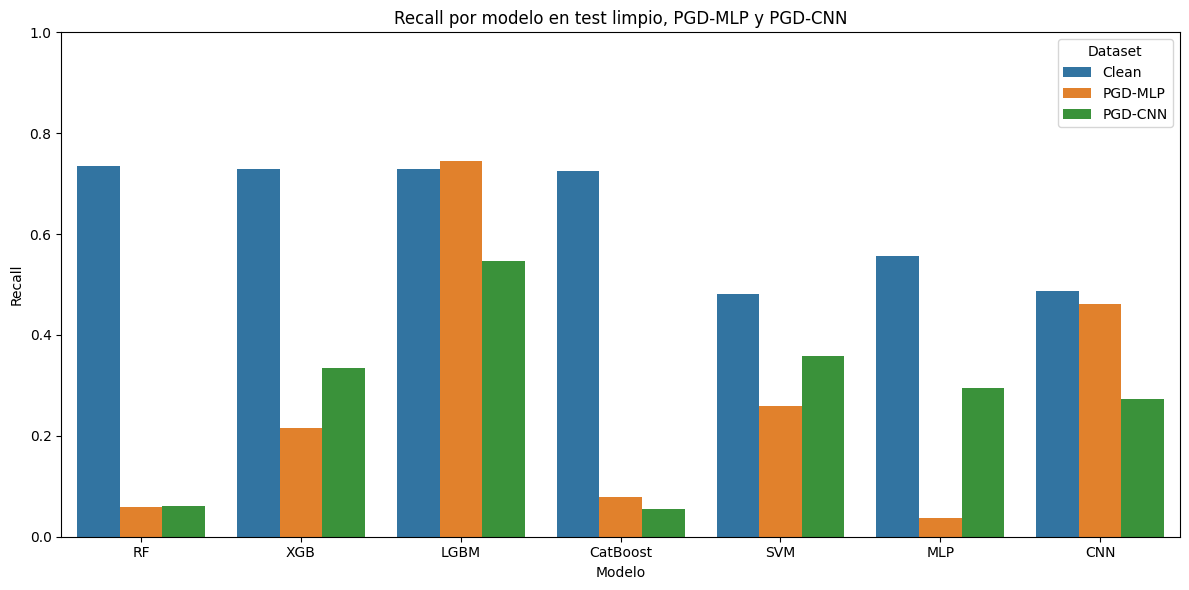

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# F1-score
# ============================================================

results_f1 = [
    {"Modelo": "RF", "Dataset": "Clean", "F1": rf_f1_clean},
    {"Modelo": "RF", "Dataset": "PGD-MLP", "F1": rf_f1_pgd_mlp},
    {"Modelo": "RF", "Dataset": "PGD-CNN", "F1": rf_f1_pgd_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "F1": xgb_f1_clean},
    {"Modelo": "XGB", "Dataset": "PGD-MLP", "F1": xgb_f1_pgd_mlp},
    {"Modelo": "XGB", "Dataset": "PGD-CNN", "F1": xgb_f1_pgd_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "F1": lgbm_f1_clean},
    {"Modelo": "LGBM", "Dataset": "PGD-MLP", "F1": lgbm_f1_pgd_mlp},
    {"Modelo": "LGBM", "Dataset": "PGD-CNN", "F1": lgbm_f1_pgd_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "F1": cat_f1_clean},
    {"Modelo": "CatBoost", "Dataset": "PGD-MLP", "F1": cat_f1_pgd_mlp},
    {"Modelo": "CatBoost", "Dataset": "PGD-CNN", "F1": cat_f1_pgd_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "F1": svm_f1_clean},
    {"Modelo": "SVM", "Dataset": "PGD-MLP", "F1": svm_f1_pgd_mlp},
    {"Modelo": "SVM", "Dataset": "PGD-CNN", "F1": svm_f1_pgd_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "F1": mlp_f1_clean},
    {"Modelo": "MLP", "Dataset": "PGD-MLP", "F1": mlp_f1_pgd_mlp},
    {"Modelo": "MLP", "Dataset": "PGD-CNN", "F1": mlp_f1_pgd_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "F1": cnn_f1_clean},
    {"Modelo": "CNN", "Dataset": "PGD-MLP", "F1": cnn_f1_pgd_mlp},
    {"Modelo": "CNN", "Dataset": "PGD-CNN", "F1": cnn_f1_pgd_cnn},
]

df_f1 = pd.DataFrame(results_f1)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_f1,
    x="Modelo",
    y="F1",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "PGD-MLP", "PGD-CNN"]
)

plt.title("F1-score por modelo en test limpio, PGD-MLP y PGD-CNN")
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# Accuracy
# ============================================================

results_acc = [
    {"Modelo": "RF", "Dataset": "Clean", "Accuracy": rf_acc_clean},
    {"Modelo": "RF", "Dataset": "PGD-MLP", "Accuracy": rf_acc_pgd_mlp},
    {"Modelo": "RF", "Dataset": "PGD-CNN", "Accuracy": rf_acc_pgd_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "Accuracy": xgb_acc_clean},
    {"Modelo": "XGB", "Dataset": "PGD-MLP", "Accuracy": xgb_acc_pgd_mlp},
    {"Modelo": "XGB", "Dataset": "PGD-CNN", "Accuracy": xgb_acc_pgd_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "Accuracy": lgbm_acc_clean},
    {"Modelo": "LGBM", "Dataset": "PGD-MLP", "Accuracy": lgbm_acc_pgd_mlp},
    {"Modelo": "LGBM", "Dataset": "PGD-CNN", "Accuracy": lgbm_acc_pgd_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "Accuracy": cat_acc_clean},
    {"Modelo": "CatBoost", "Dataset": "PGD-MLP", "Accuracy": cat_acc_pgd_mlp},
    {"Modelo": "CatBoost", "Dataset": "PGD-CNN", "Accuracy": cat_acc_pgd_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "Accuracy": svm_acc_clean},
    {"Modelo": "SVM", "Dataset": "PGD-MLP", "Accuracy": svm_acc_pgd_mlp},
    {"Modelo": "SVM", "Dataset": "PGD-CNN", "Accuracy": svm_acc_pgd_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "Accuracy": mlp_acc_clean},
    {"Modelo": "MLP", "Dataset": "PGD-MLP", "Accuracy": mlp_acc_pgd_mlp},
    {"Modelo": "MLP", "Dataset": "PGD-CNN", "Accuracy": mlp_acc_pgd_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "Accuracy": cnn_acc_clean},
    {"Modelo": "CNN", "Dataset": "PGD-MLP", "Accuracy": cnn_acc_pgd_mlp},
    {"Modelo": "CNN", "Dataset": "PGD-CNN", "Accuracy": cnn_acc_pgd_cnn},
]

df_acc = pd.DataFrame(results_acc)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_acc,
    x="Modelo",
    y="Accuracy",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "PGD-MLP", "PGD-CNN"]
)

plt.title("Accuracy por modelo en test limpio, PGD-MLP y PGD-CNN")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# Recall
# ============================================================

results_recall = [
    {"Modelo": "RF", "Dataset": "Clean", "Recall": rf_recall_clean},
    {"Modelo": "RF", "Dataset": "PGD-MLP", "Recall": rf_recall_pgd_mlp},
    {"Modelo": "RF", "Dataset": "PGD-CNN", "Recall": rf_recall_pgd_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "Recall": xgb_recall_clean},
    {"Modelo": "XGB", "Dataset": "PGD-MLP", "Recall": xgb_recall_pgd_mlp},
    {"Modelo": "XGB", "Dataset": "PGD-CNN", "Recall": xgb_recall_pgd_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "Recall": lgbm_recall_clean},
    {"Modelo": "LGBM", "Dataset": "PGD-MLP", "Recall": lgbm_recall_pgd_mlp},
    {"Modelo": "LGBM", "Dataset": "PGD-CNN", "Recall": lgbm_recall_pgd_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "Recall": cat_recall_clean},
    {"Modelo": "CatBoost", "Dataset": "PGD-MLP", "Recall": cat_recall_pgd_mlp},
    {"Modelo": "CatBoost", "Dataset": "PGD-CNN", "Recall": cat_recall_pgd_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "Recall": svm_recall_clean},
    {"Modelo": "SVM", "Dataset": "PGD-MLP", "Recall": svm_recall_pgd_mlp},
    {"Modelo": "SVM", "Dataset": "PGD-CNN", "Recall": svm_recall_pgd_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "Recall": mlp_recall_clean},
    {"Modelo": "MLP", "Dataset": "PGD-MLP", "Recall": mlp_recall_pgd_mlp},
    {"Modelo": "MLP", "Dataset": "PGD-CNN", "Recall": mlp_recall_pgd_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "Recall": cnn_recall_clean},
    {"Modelo": "CNN", "Dataset": "PGD-MLP", "Recall": cnn_recall_pgd_mlp},
    {"Modelo": "CNN", "Dataset": "PGD-CNN", "Recall": cnn_recall_pgd_cnn},
]

df_recall = pd.DataFrame(results_recall)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_recall,
    x="Modelo",
    y="Recall",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "PGD-MLP", "PGD-CNN"]
)

plt.title("Recall por modelo en test limpio, PGD-MLP y PGD-CNN")
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()


In [28]:
# ========================================================
# FASE 4. LANZAR ATAQUE FGSM
# ========================================================

print("Lanzando ataque FGSM sobre MLP y CNN...")

# -----------------------------
# FGSM sobre el MLP
# -----------------------------
ataque_fgsm_mlp = FastGradientMethod(
    estimator=clasificador_art_mlp,
    eps=eps_vector,
    eps_step=eps_step_vector,
    batch_size=128,
)

x_test_fgsm_mlp = ataque_fgsm_mlp.generate(x=x_test_mlp_attack)
print("¡Tráfico adversario FGSM para el MLP generado con éxito!")


Lanzando ataque FGSM sobre MLP y CNN...
¡Tráfico adversario FGSM para el MLP generado con éxito!


In [29]:
# -----------------------------
# FGSM sobre la CNN
# -----------------------------
ataque_fgsm_cnn = FastGradientMethod(
    estimator=clasificador_art_cnn,
    eps=eps_vector_cnn,
    eps_step=eps_step_vector_cnn,
    batch_size=128,
)

with tf.device(INFER_DEVICE):
    x_test_fgsm_cnn = ataque_fgsm_cnn.generate(x=x_test_cnn_attack)

print("¡Tráfico adversario FGSM para la CNN generado con éxito!")

¡Tráfico adversario FGSM para la CNN generado con éxito!


In [30]:
# =========================
# FGSM generado sobre MLP
# =========================
x_test_fgsm_mlp_std = x_test_fgsm_mlp.astype(np.float32)
x_test_fgsm_mlp_raw = mlp_scaler.inverse_transform(x_test_fgsm_mlp_std).astype(np.float32)
x_test_fgsm_mlp_minmax = cnn_scaler.transform(x_test_fgsm_mlp_raw).astype(np.float32)
x_test_fgsm_mlp_cnn = x_test_fgsm_mlp_minmax.reshape(
    x_test_fgsm_mlp_minmax.shape[0],
    x_test_fgsm_mlp_minmax.shape[1],
    1
)

# =========================
# FGSM generado sobre CNN
# =========================
x_test_fgsm_cnn_cnn = x_test_fgsm_cnn.astype(np.float32)
x_test_fgsm_cnn_minmax = x_test_fgsm_cnn_cnn.reshape(
    x_test_fgsm_cnn_cnn.shape[0],
    x_test_fgsm_cnn_cnn.shape[1]
).astype(np.float32)
x_test_fgsm_cnn_raw = cnn_scaler.inverse_transform(x_test_fgsm_cnn_minmax).astype(np.float32)
x_test_fgsm_cnn_std = mlp_scaler.transform(x_test_fgsm_cnn_raw).astype(np.float32)


In [31]:
# =====================================================
# RF
# =====================================================

y_test_pred_rf_fgsm_mlp = rf_model.predict(x_test_fgsm_mlp_raw)
rf_acc_fgsm_mlp = accuracy_score(y_test_np01, y_test_pred_rf_fgsm_mlp)
rf_f1_fgsm_mlp = f1_score(y_test_np01, y_test_pred_rf_fgsm_mlp)
rf_recall_fgsm_mlp = recall_score(y_test_np01, y_test_pred_rf_fgsm_mlp)

print(f"\nRF Accuracy FGSM-MLP: {rf_acc_fgsm_mlp:.4f}")
print(f"RF F1 FGSM-MLP: {rf_f1_fgsm_mlp:.4f}")
print(f"RF Recall FGSM-MLP: {rf_recall_fgsm_mlp:.4f}")

y_test_pred_rf_fgsm_cnn = rf_model.predict(x_test_fgsm_cnn_raw)
rf_acc_fgsm_cnn = accuracy_score(y_test_np01, y_test_pred_rf_fgsm_cnn)
rf_f1_fgsm_cnn = f1_score(y_test_np01, y_test_pred_rf_fgsm_cnn)
rf_recall_fgsm_cnn = recall_score(y_test_np01, y_test_pred_rf_fgsm_cnn)

print(f"\nRF Accuracy FGSM-CNN: {rf_acc_fgsm_cnn:.4f}")
print(f"RF F1 FGSM-CNN: {rf_f1_fgsm_cnn:.4f}")
print(f"RF Recall FGSM-CNN: {rf_recall_fgsm_cnn:.4f}")

# =====================================================
# XGBOOST
# =====================================================

y_test_pred_xgb_fgsm_mlp = xgb_model.predict(x_test_fgsm_mlp_raw)
xgb_acc_fgsm_mlp = accuracy_score(y_test_np01, y_test_pred_xgb_fgsm_mlp)
xgb_f1_fgsm_mlp = f1_score(y_test_np01, y_test_pred_xgb_fgsm_mlp)
xgb_recall_fgsm_mlp = recall_score(y_test_np01, y_test_pred_xgb_fgsm_mlp)

print(f"\nXGB Accuracy FGSM-MLP: {xgb_acc_fgsm_mlp:.4f}")
print(f"XGB F1 FGSM-MLP: {xgb_f1_fgsm_mlp:.4f}")
print(f"XGB Recall FGSM-MLP: {xgb_recall_fgsm_mlp:.4f}")

y_test_pred_xgb_fgsm_cnn = xgb_model.predict(x_test_fgsm_cnn_raw)
xgb_acc_fgsm_cnn = accuracy_score(y_test_np01, y_test_pred_xgb_fgsm_cnn)
xgb_f1_fgsm_cnn = f1_score(y_test_np01, y_test_pred_xgb_fgsm_cnn)
xgb_recall_fgsm_cnn = recall_score(y_test_np01, y_test_pred_xgb_fgsm_cnn)

print(f"\nXGB Accuracy FGSM-CNN: {xgb_acc_fgsm_cnn:.4f}")
print(f"XGB F1 FGSM-CNN: {xgb_f1_fgsm_cnn:.4f}")
print(f"XGB Recall FGSM-CNN: {xgb_recall_fgsm_cnn:.4f}")

# =====================================================
# LIGHTGBM
# =====================================================

y_test_pred_lgbm_fgsm_mlp = lgbm_model.predict(x_test_fgsm_mlp_raw)
lgbm_acc_fgsm_mlp = accuracy_score(y_test_np01, y_test_pred_lgbm_fgsm_mlp)
lgbm_f1_fgsm_mlp = f1_score(y_test_np01, y_test_pred_lgbm_fgsm_mlp)
lgbm_recall_fgsm_mlp = recall_score(y_test_np01, y_test_pred_lgbm_fgsm_mlp)

print(f"\nLGBM Accuracy FGSM-MLP: {lgbm_acc_fgsm_mlp:.4f}")
print(f"LGBM F1 FGSM-MLP: {lgbm_f1_fgsm_mlp:.4f}")
print(f"LGBM Recall FGSM-MLP: {lgbm_recall_fgsm_mlp:.4f}")

y_test_pred_lgbm_fgsm_cnn = lgbm_model.predict(x_test_fgsm_cnn_raw)
lgbm_acc_fgsm_cnn = accuracy_score(y_test_np01, y_test_pred_lgbm_fgsm_cnn)
lgbm_f1_fgsm_cnn = f1_score(y_test_np01, y_test_pred_lgbm_fgsm_cnn)
lgbm_recall_fgsm_cnn = recall_score(y_test_np01, y_test_pred_lgbm_fgsm_cnn)

print(f"\nLGBM Accuracy FGSM-CNN: {lgbm_acc_fgsm_cnn:.4f}")
print(f"LGBM F1 FGSM-CNN: {lgbm_f1_fgsm_cnn:.4f}")
print(f"LGBM Recall FGSM-CNN: {lgbm_recall_fgsm_cnn:.4f}")

# =====================================================
# CATBOOST
# =====================================================

y_test_pred_cat_fgsm_mlp = cat_model.predict(x_test_fgsm_mlp_raw)
cat_acc_fgsm_mlp = accuracy_score(y_test_np01, y_test_pred_cat_fgsm_mlp)
cat_f1_fgsm_mlp = f1_score(y_test_np01, y_test_pred_cat_fgsm_mlp)
cat_recall_fgsm_mlp = recall_score(y_test_np01, y_test_pred_cat_fgsm_mlp)

print(f"\nCatBoost Accuracy FGSM-MLP: {cat_acc_fgsm_mlp:.4f}")
print(f"CatBoost F1 FGSM-MLP: {cat_f1_fgsm_mlp:.4f}")
print(f"CatBoost Recall FGSM-MLP: {cat_recall_fgsm_mlp:.4f}")

y_test_pred_cat_fgsm_cnn = cat_model.predict(x_test_fgsm_cnn_raw)
cat_acc_fgsm_cnn = accuracy_score(y_test_np01, y_test_pred_cat_fgsm_cnn)
cat_f1_fgsm_cnn = f1_score(y_test_np01, y_test_pred_cat_fgsm_cnn)
cat_recall_fgsm_cnn = recall_score(y_test_np01, y_test_pred_cat_fgsm_cnn)

print(f"\nCatBoost Accuracy FGSM-CNN: {cat_acc_fgsm_cnn:.4f}")
print(f"CatBoost F1 FGSM-CNN: {cat_f1_fgsm_cnn:.4f}")
print(f"CatBoost Recall FGSM-CNN: {cat_recall_fgsm_cnn:.4f}")

# =====================================================
# SVM
# =====================================================

y_test_pred_svm_fgsm_mlp = svm_model.predict(x_test_fgsm_mlp_std)
svm_acc_fgsm_mlp = accuracy_score(y_test_np01, y_test_pred_svm_fgsm_mlp)
svm_f1_fgsm_mlp = f1_score(y_test_np01, y_test_pred_svm_fgsm_mlp)
svm_recall_fgsm_mlp = recall_score(y_test_np01, y_test_pred_svm_fgsm_mlp)

print(f"\nSVM Accuracy FGSM-MLP: {svm_acc_fgsm_mlp:.4f}")
print(f"SVM F1 FGSM-MLP: {svm_f1_fgsm_mlp:.4f}")
print(f"SVM Recall FGSM-MLP: {svm_recall_fgsm_mlp:.4f}")

y_test_pred_svm_fgsm_cnn = svm_model.predict(x_test_fgsm_cnn_std)
svm_acc_fgsm_cnn = accuracy_score(y_test_np01, y_test_pred_svm_fgsm_cnn)
svm_f1_fgsm_cnn = f1_score(y_test_np01, y_test_pred_svm_fgsm_cnn)
svm_recall_fgsm_cnn = recall_score(y_test_np01, y_test_pred_svm_fgsm_cnn)

print(f"\nSVM Accuracy FGSM-CNN: {svm_acc_fgsm_cnn:.4f}")
print(f"SVM F1 FGSM-CNN: {svm_f1_fgsm_cnn:.4f}")
print(f"SVM Recall FGSM-CNN: {svm_recall_fgsm_cnn:.4f}")

# =====================================================
# MLP
# =====================================================

y_test_pred_mlp_fgsm_mlp = mlp_predict_labels(x_test_fgsm_mlp_std)
mlp_acc_fgsm_mlp = accuracy_score(y_test_np01, y_test_pred_mlp_fgsm_mlp)
mlp_f1_fgsm_mlp = f1_score(y_test_np01, y_test_pred_mlp_fgsm_mlp)
mlp_recall_fgsm_mlp = recall_score(y_test_np01, y_test_pred_mlp_fgsm_mlp)

print(f"\nMLP Accuracy FGSM-MLP: {mlp_acc_fgsm_mlp:.4f}")
print(f"MLP F1 FGSM-MLP: {mlp_f1_fgsm_mlp:.4f}")
print(f"MLP Recall FGSM-MLP: {mlp_recall_fgsm_mlp:.4f}")

y_test_pred_mlp_fgsm_cnn = mlp_predict_labels(x_test_fgsm_cnn_std)
mlp_acc_fgsm_cnn = accuracy_score(y_test_np01, y_test_pred_mlp_fgsm_cnn)
mlp_f1_fgsm_cnn = f1_score(y_test_np01, y_test_pred_mlp_fgsm_cnn)
mlp_recall_fgsm_cnn = recall_score(y_test_np01, y_test_pred_mlp_fgsm_cnn)

print(f"\nMLP Accuracy FGSM-CNN: {mlp_acc_fgsm_cnn:.4f}")
print(f"MLP F1 FGSM-CNN: {mlp_f1_fgsm_cnn:.4f}")
print(f"MLP Recall FGSM-CNN: {mlp_recall_fgsm_cnn:.4f}")

# =====================================================
# CNN
# =====================================================

y_test_pred_cnn_fgsm_mlp = cnn_predict_labels(x_test_fgsm_mlp_cnn)
cnn_acc_fgsm_mlp = accuracy_score(y_test_np01, y_test_pred_cnn_fgsm_mlp)
cnn_f1_fgsm_mlp = f1_score(y_test_np01, y_test_pred_cnn_fgsm_mlp)
cnn_recall_fgsm_mlp = recall_score(y_test_np01, y_test_pred_cnn_fgsm_mlp)

print(f"\nCNN Accuracy FGSM-MLP: {cnn_acc_fgsm_mlp:.4f}")
print(f"CNN F1 FGSM-MLP: {cnn_f1_fgsm_mlp:.4f}")
print(f"CNN Recall FGSM-MLP: {cnn_recall_fgsm_mlp:.4f}")

y_test_pred_cnn_fgsm_cnn = cnn_predict_labels(x_test_fgsm_cnn_cnn)
cnn_acc_fgsm_cnn = accuracy_score(y_test_np01, y_test_pred_cnn_fgsm_cnn)
cnn_f1_fgsm_cnn = f1_score(y_test_np01, y_test_pred_cnn_fgsm_cnn)
cnn_recall_fgsm_cnn = recall_score(y_test_np01, y_test_pred_cnn_fgsm_cnn)

print(f"\nCNN Accuracy FGSM-CNN: {cnn_acc_fgsm_cnn:.4f}")
print(f"CNN F1 FGSM-CNN: {cnn_f1_fgsm_cnn:.4f}")
print(f"CNN Recall FGSM-CNN: {cnn_recall_fgsm_cnn:.4f}")



RF Accuracy FGSM-MLP: 0.5903
RF F1 FGSM-MLP: 0.1762
RF Recall FGSM-MLP: 0.0975

RF Accuracy FGSM-CNN: 0.4879
RF F1 FGSM-CNN: 0.1093
RF Recall FGSM-CNN: 0.0699

XGB Accuracy FGSM-MLP: 0.5829
XGB F1 FGSM-MLP: 0.2444
XGB Recall FGSM-MLP: 0.1501

XGB Accuracy FGSM-CNN: 0.6767
XGB F1 FGSM-CNN: 0.5133
XGB Recall FGSM-CNN: 0.3794


/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LGBM Accuracy FGSM-MLP: 0.6819
LGBM F1 FGSM-MLP: 0.5684
LGBM Recall FGSM-MLP: 0.4660

LGBM Accuracy FGSM-CNN: 0.6537
LGBM F1 FGSM-CNN: 0.6050
LGBM Recall FGSM-CNN: 0.5902

CatBoost Accuracy FGSM-MLP: 0.5637
CatBoost F1 FGSM-MLP: 0.2151
CatBoost Recall FGSM-MLP: 0.1331

CatBoost Accuracy FGSM-CNN: 0.5461
CatBoost F1 FGSM-CNN: 0.1321
CatBoost Recall FGSM-CNN: 0.0769

SVM Accuracy FGSM-MLP: 0.6003
SVM F1 FGSM-MLP: 0.2532
SVM Recall FGSM-MLP: 0.1508

SVM Accuracy FGSM-CNN: 0.6531
SVM F1 FGSM-CNN: 0.4750
SVM Recall FGSM-CNN: 0.3492

MLP Accuracy FGSM-MLP: 0.5652
MLP F1 FGSM-MLP: 0.0761
MLP Recall FGSM-MLP: 0.0398

MLP Accuracy FGSM-CNN: 0.6170
MLP F1 FGSM-CNN: 0.3823
MLP Recall FGSM-CNN: 0.2638

CNN Accuracy FGSM-MLP: 0.7255
CNN F1 FGSM-MLP: 0.5723
CNN Recall FGSM-MLP: 0.4088

CNN Accuracy FGSM-CNN: 0.6792
CNN F1 FGSM-CNN: 0.4488
CNN Recall FGSM-CNN: 0.2906


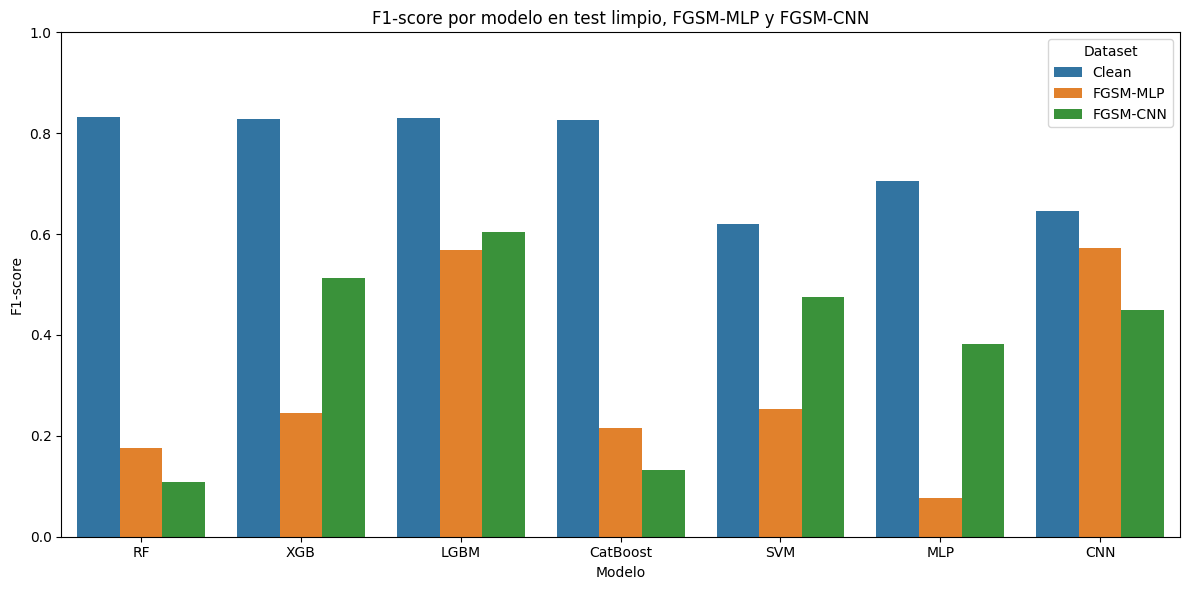

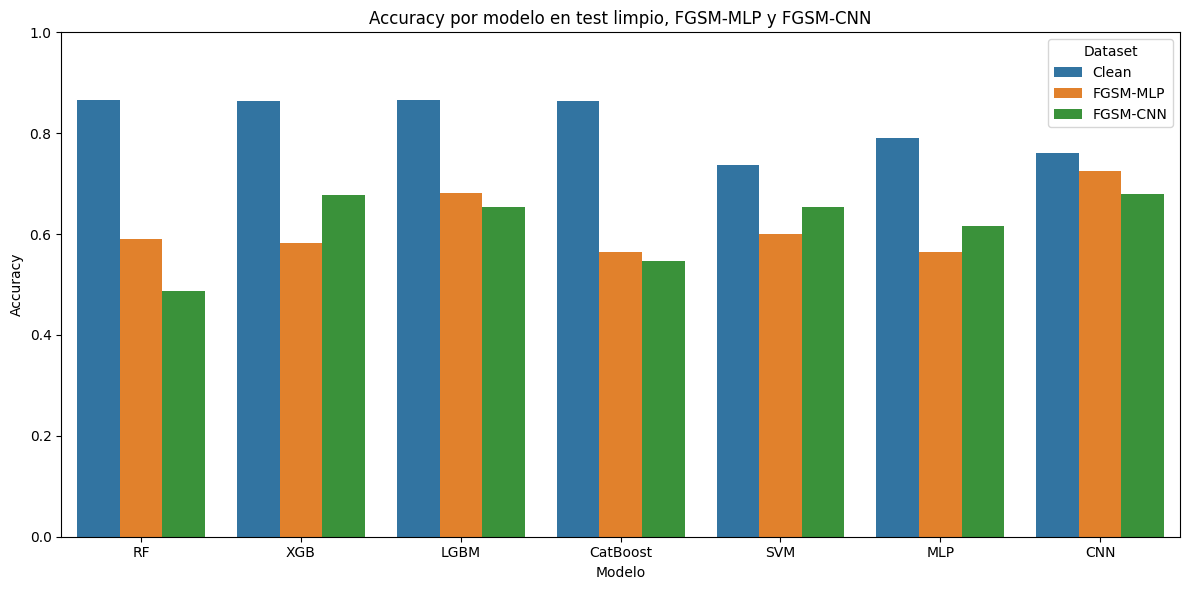

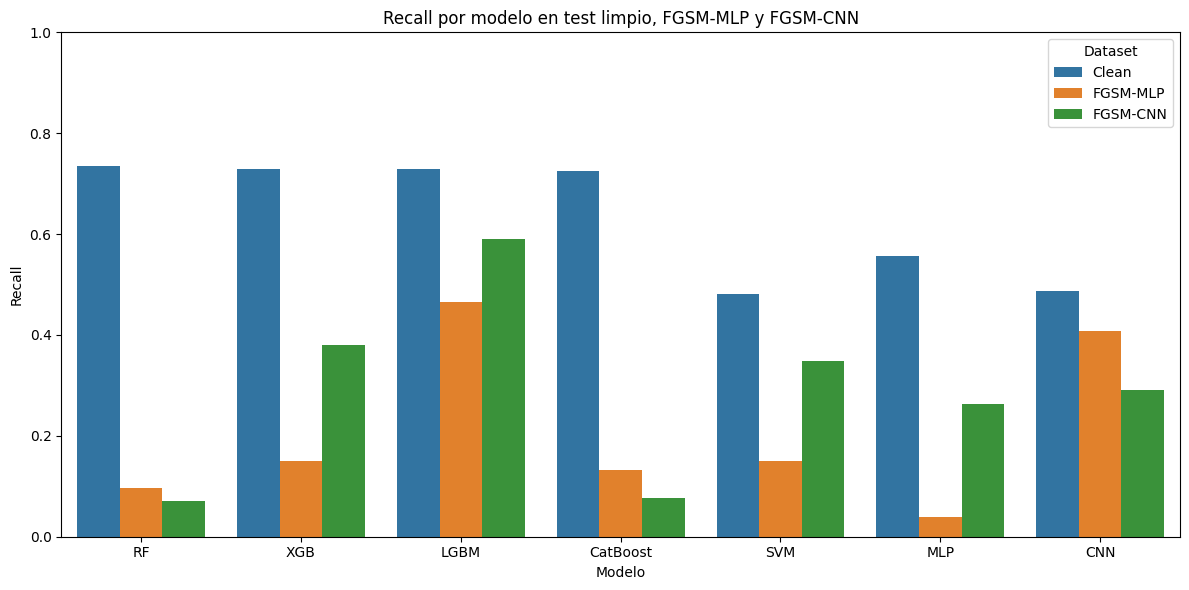

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# F1-score
# ============================================================

results_f1 = [
    {"Modelo": "RF", "Dataset": "Clean", "F1": rf_f1_clean},
    {"Modelo": "RF", "Dataset": "FGSM-MLP", "F1": rf_f1_fgsm_mlp},
    {"Modelo": "RF", "Dataset": "FGSM-CNN", "F1": rf_f1_fgsm_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "F1": xgb_f1_clean},
    {"Modelo": "XGB", "Dataset": "FGSM-MLP", "F1": xgb_f1_fgsm_mlp},
    {"Modelo": "XGB", "Dataset": "FGSM-CNN", "F1": xgb_f1_fgsm_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "F1": lgbm_f1_clean},
    {"Modelo": "LGBM", "Dataset": "FGSM-MLP", "F1": lgbm_f1_fgsm_mlp},
    {"Modelo": "LGBM", "Dataset": "FGSM-CNN", "F1": lgbm_f1_fgsm_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "F1": cat_f1_clean},
    {"Modelo": "CatBoost", "Dataset": "FGSM-MLP", "F1": cat_f1_fgsm_mlp},
    {"Modelo": "CatBoost", "Dataset": "FGSM-CNN", "F1": cat_f1_fgsm_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "F1": svm_f1_clean},
    {"Modelo": "SVM", "Dataset": "FGSM-MLP", "F1": svm_f1_fgsm_mlp},
    {"Modelo": "SVM", "Dataset": "FGSM-CNN", "F1": svm_f1_fgsm_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "F1": mlp_f1_clean},
    {"Modelo": "MLP", "Dataset": "FGSM-MLP", "F1": mlp_f1_fgsm_mlp},
    {"Modelo": "MLP", "Dataset": "FGSM-CNN", "F1": mlp_f1_fgsm_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "F1": cnn_f1_clean},
    {"Modelo": "CNN", "Dataset": "FGSM-MLP", "F1": cnn_f1_fgsm_mlp},
    {"Modelo": "CNN", "Dataset": "FGSM-CNN", "F1": cnn_f1_fgsm_cnn},
]

df_f1 = pd.DataFrame(results_f1)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_f1,
    x="Modelo",
    y="F1",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "FGSM-MLP", "FGSM-CNN"]
)

plt.title("F1-score por modelo en test limpio, FGSM-MLP y FGSM-CNN")
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# Accuracy
# ============================================================

results_acc = [
    {"Modelo": "RF", "Dataset": "Clean", "Accuracy": rf_acc_clean},
    {"Modelo": "RF", "Dataset": "FGSM-MLP", "Accuracy": rf_acc_fgsm_mlp},
    {"Modelo": "RF", "Dataset": "FGSM-CNN", "Accuracy": rf_acc_fgsm_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "Accuracy": xgb_acc_clean},
    {"Modelo": "XGB", "Dataset": "FGSM-MLP", "Accuracy": xgb_acc_fgsm_mlp},
    {"Modelo": "XGB", "Dataset": "FGSM-CNN", "Accuracy": xgb_acc_fgsm_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "Accuracy": lgbm_acc_clean},
    {"Modelo": "LGBM", "Dataset": "FGSM-MLP", "Accuracy": lgbm_acc_fgsm_mlp},
    {"Modelo": "LGBM", "Dataset": "FGSM-CNN", "Accuracy": lgbm_acc_fgsm_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "Accuracy": cat_acc_clean},
    {"Modelo": "CatBoost", "Dataset": "FGSM-MLP", "Accuracy": cat_acc_fgsm_mlp},
    {"Modelo": "CatBoost", "Dataset": "FGSM-CNN", "Accuracy": cat_acc_fgsm_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "Accuracy": svm_acc_clean},
    {"Modelo": "SVM", "Dataset": "FGSM-MLP", "Accuracy": svm_acc_fgsm_mlp},
    {"Modelo": "SVM", "Dataset": "FGSM-CNN", "Accuracy": svm_acc_fgsm_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "Accuracy": mlp_acc_clean},
    {"Modelo": "MLP", "Dataset": "FGSM-MLP", "Accuracy": mlp_acc_fgsm_mlp},
    {"Modelo": "MLP", "Dataset": "FGSM-CNN", "Accuracy": mlp_acc_fgsm_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "Accuracy": cnn_acc_clean},
    {"Modelo": "CNN", "Dataset": "FGSM-MLP", "Accuracy": cnn_acc_fgsm_mlp},
    {"Modelo": "CNN", "Dataset": "FGSM-CNN", "Accuracy": cnn_acc_fgsm_cnn},
]

df_acc = pd.DataFrame(results_acc)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_acc,
    x="Modelo",
    y="Accuracy",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "FGSM-MLP", "FGSM-CNN"]
)

plt.title("Accuracy por modelo en test limpio, FGSM-MLP y FGSM-CNN")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# Recall
# ============================================================

results_recall = [
    {"Modelo": "RF", "Dataset": "Clean", "Recall": rf_recall_clean},
    {"Modelo": "RF", "Dataset": "FGSM-MLP", "Recall": rf_recall_fgsm_mlp},
    {"Modelo": "RF", "Dataset": "FGSM-CNN", "Recall": rf_recall_fgsm_cnn},

    {"Modelo": "XGB", "Dataset": "Clean", "Recall": xgb_recall_clean},
    {"Modelo": "XGB", "Dataset": "FGSM-MLP", "Recall": xgb_recall_fgsm_mlp},
    {"Modelo": "XGB", "Dataset": "FGSM-CNN", "Recall": xgb_recall_fgsm_cnn},

    {"Modelo": "LGBM", "Dataset": "Clean", "Recall": lgbm_recall_clean},
    {"Modelo": "LGBM", "Dataset": "FGSM-MLP", "Recall": lgbm_recall_fgsm_mlp},
    {"Modelo": "LGBM", "Dataset": "FGSM-CNN", "Recall": lgbm_recall_fgsm_cnn},

    {"Modelo": "CatBoost", "Dataset": "Clean", "Recall": cat_recall_clean},
    {"Modelo": "CatBoost", "Dataset": "FGSM-MLP", "Recall": cat_recall_fgsm_mlp},
    {"Modelo": "CatBoost", "Dataset": "FGSM-CNN", "Recall": cat_recall_fgsm_cnn},

    {"Modelo": "SVM", "Dataset": "Clean", "Recall": svm_recall_clean},
    {"Modelo": "SVM", "Dataset": "FGSM-MLP", "Recall": svm_recall_fgsm_mlp},
    {"Modelo": "SVM", "Dataset": "FGSM-CNN", "Recall": svm_recall_fgsm_cnn},

    {"Modelo": "MLP", "Dataset": "Clean", "Recall": mlp_recall_clean},
    {"Modelo": "MLP", "Dataset": "FGSM-MLP", "Recall": mlp_recall_fgsm_mlp},
    {"Modelo": "MLP", "Dataset": "FGSM-CNN", "Recall": mlp_recall_fgsm_cnn},

    {"Modelo": "CNN", "Dataset": "Clean", "Recall": cnn_recall_clean},
    {"Modelo": "CNN", "Dataset": "FGSM-MLP", "Recall": cnn_recall_fgsm_mlp},
    {"Modelo": "CNN", "Dataset": "FGSM-CNN", "Recall": cnn_recall_fgsm_cnn},
]

df_recall = pd.DataFrame(results_recall)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_recall,
    x="Modelo",
    y="Recall",
    hue="Dataset",
    order=["RF", "XGB", "LGBM", "CatBoost", "SVM", "MLP", "CNN"],
    hue_order=["Clean", "FGSM-MLP", "FGSM-CNN"]
)

plt.title("Recall por modelo en test limpio, FGSM-MLP y FGSM-CNN")
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.xlabel("Modelo")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()
